In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import sys, os
import glob
from pathlib import Path

#import astropy
from astropy.table import vstack, Table, QTable, join
from astropy.io import ascii 
from astropy.io import fits
from astropy.convolution import convolve, Box1DKernel
import astropy.units as u
from astropy.coordinates import SkyCoord


import synphot
from synphot import SourceSpectrum
from synphot import units as su
from synphot import SpectralElement
from synphot.models import Empirical1D
from synphot.observation import Observation



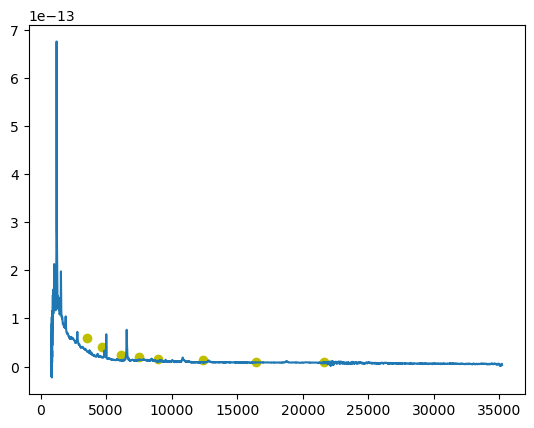

In [23]:
filtdir = '/Users/eglikman/GoogleDrive/Research/filters/'
templateQSO = '/Users/eglikman/Research/templates/qso_template.txt'
spec = ascii.read('/Users/eglikman/Research/templates/qso_template.txt')
templateWave = spec['col1']
templateFlux = spec['col2']

# and array of the effective wavelengths
lam = [3542.,4686., 6165., 7481., 8923., 12355., 16458., 21603.] * u.AA

# this is the redshift of the quasar you are comparing to -- change it for each object, e.g. in a loop
zsp = 0.5

# create a spectrum object from the template
sp = SourceSpectrum(Empirical1D, points=templateWave*u.AA, lookup_table=templateFlux*su.FLAM, z=zsp)

#sp.plot() # sanity check -- notice the figure shifts when chaning zsp; comment out if all looks good

wphot = lam.value/(1+zsp)
# replace these with the filter files for your data
filt_files = ["u.dat","g.dat","r.dat","i.dat","z.dat","2MASS_2MASS.J.dat.txt","2MASS_2MASS.H.dat.txt","2MASS_2MASS.Ks.dat.txt"]
synth_flx = [] # this will be populated by the spectrophotometry in each filter

###Uncomment this.
## this code does a quick scaling to shift the template to the same y-scale as your data
## Here wphot is the wavelengths for your filters that you have been plotting
## and flam are your fluxes for each quasar
# srat = fit_composite(lam.value, np.array(synth_flx), wphot, np.array(flam))

for filt_file in filt_files:           
    bp = SpectralElement.from_file(filtdir+filt_file) # bp stands for bandpass -- it is the filter transmission curve
    observation = Observation(sp, bp, force='extrap') # this command applies the filter to the data to get a flux for that filter
    synth_flx.append(observation.effstim('flam').value) # this adds that value to the synth_flx table as it loops through the filtrs

    # plot the results -- in the rest frame

    
## once you have a value for 'srat' above, you will edit these commands to multiply
## srat*templateFlux and srat*synth_flx
plt.figure()
plt.plot(templateWave,templateFlux,label='template spectrum') 
plt.scatter(lam.value, synth_flx, color='y') # plot the synthetic photometry        
#plt.ylim(0,2e-16)


